In [1]:
# ==============================================================================
# PIPELINE 7: Supervised Learning - Predicting Market Failure (Lot-Level)
# ==============================================================================
import pandas as pd
import numpy as np

from src.training.supervised import prepare_supervised_data, tune_supervised_model
from src.training.evaluation import evaluate_classification
from src.training.visualization import plot_confusion_matrix_heatmap, plot_pr_curve, plot_feature_importance, plot_grouped_feature_importance

pd.set_option('display.max_columns', None)
df_ml = pd.read_parquet("data/prepared/ted_prepared.parquet")

In [2]:
# ------------------------------------------------------------------------------
# STEP 1: Feature Setup & Strict Group Splitting
# ------------------------------------------------------------------------------

# TARGET VARIABLE: Market Failure
# Defined strictly as procurement lots receiving 1 or 0 bids, effectively neutralizing competition.
df_ml['TARGET_MARKET_FAILURE'] = (df_ml['NUMBER_OF_TENDERS'] <= 1).astype(int)

# CATEGORICAL FEATURES: Structural context of the procurement lot.
categorical_cols = [
    'ISO_COUNTRY_CODE', 'CAE_TYPE', 'MAIN_ACTIVITY', 
    'TOP_TYPE', 'CPV', 'TYPE_OF_CONTRACT', 'CRIT_CODE'
]

# NUMERICAL & BOOLEAN FEATURES: Financial, temporal, and barrier constraints.
# LOT_AWARD_VALUE_EUR is used instead of TARGET_AWARD_VALUE_EUR to maintain lot-level integrity.
numeric_cols = [
    'LOT_AWARD_VALUE_EUR',     # Financial scale
    'DURATION',                # Temporal commitment
    'PREPARATION_DAYS',        # Bureaucratic barrier
    'LOTS_NUMBER',             # Fragmentation
    'NUTS_REGION_COUNT',       # Geographical barrier
    'NUTS_LEVEL',              # Granularity of execution
    'B_EU_FUNDS',              # Funding origin
    'IS_FRAMEWORK',            # Contract structure
    'COOPERATIVE_PURCHASING',  # Centralized purchasing barrier
    'B_RECURRENT_PROCUREMENT' # Supplier lock-in indicator
]

# GroupShuffleSplit isolates notices to prevent leakage across parallel lots.
X_train, X_test, y_train, y_test, groups_train = prepare_supervised_data(
    df=df_ml,
    target_col='TARGET_MARKET_FAILURE',
    group_col='ID_NOTICE',
    feature_cols=categorical_cols + numeric_cols,
    test_size=0.2
)


--- Evaluation: XGBoost ---
--- Classification Report ---
              precision    recall  f1-score   support

           0       0.65      0.82      0.72    176594
           1       0.88      0.74      0.81    310266

    accuracy                           0.77    486860
   macro avg       0.76      0.78      0.76    486860
weighted avg       0.80      0.77      0.78    486860

PR-AUC  (Precision-Recall Area Under Curve): 0.9275
ROC-AUC (Receiver Operating Characteristic): 0.8689


<Figure size 600x400 with 0 Axes>

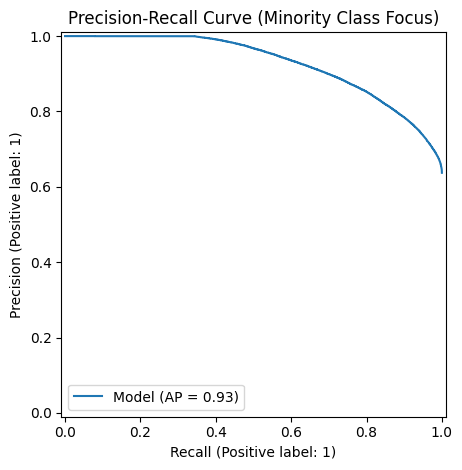

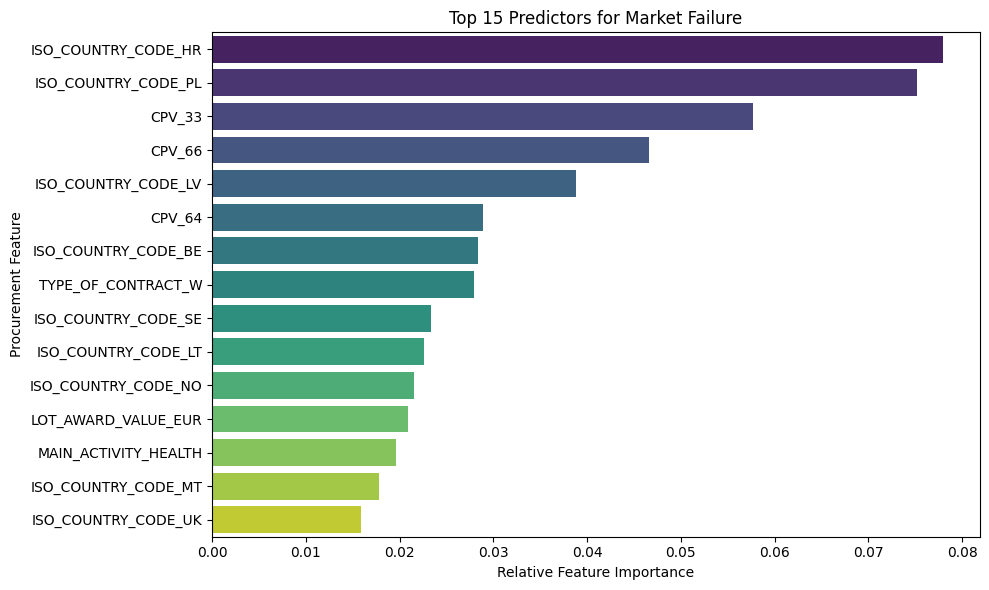

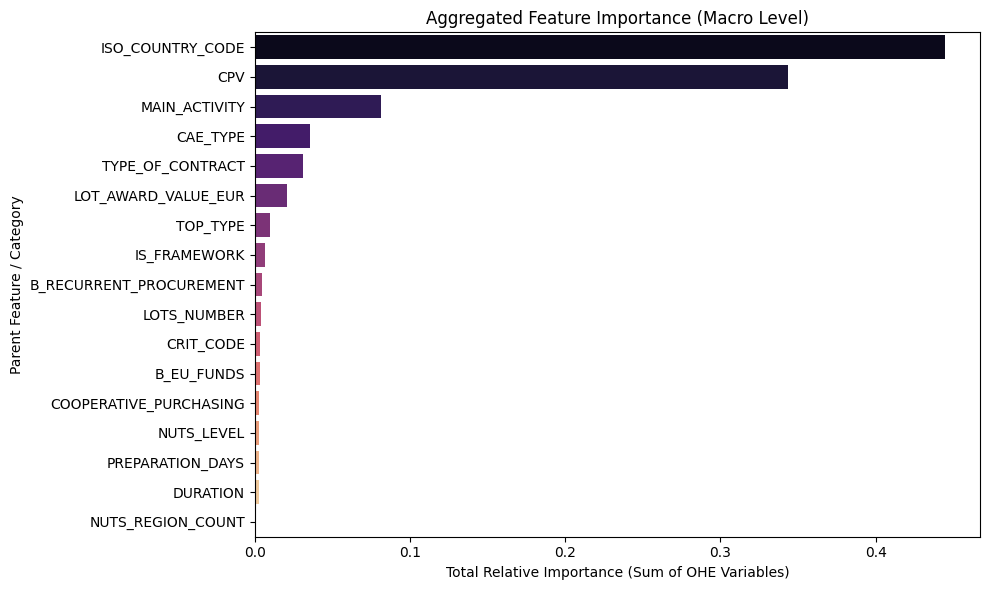

In [3]:
# ------------------------------------------------------------------------------
# STEP 2: XGBoost (Advanced Gradient Boosting)
# ------------------------------------------------------------------------------
# XGBoost dynamically handles the severe class imbalance via the calculated scale_pos_weight.
model_xgb = tune_supervised_model(
    X_train, y_train, groups_train, categorical_cols, numeric_cols, model_name='xgboost'
)

preds_xgb = model_xgb.predict(X_test)
probs_xgb = model_xgb.predict_proba(X_test)[:, 1]

print("\n--- Evaluation: XGBoost ---")
evaluate_classification(y_test, preds_xgb, probs_xgb)

# Using PR Curves to visualize performance on the imbalanced minority class
plot_pr_curve(y_test, probs_xgb)
plot_feature_importance(model_xgb, numeric_cols, categorical_cols, top_n=15)
plot_grouped_feature_importance(model_xgb, numeric_cols, categorical_cols)


--- Evaluation: Logistic Regression ---
--- Classification Report ---
              precision    recall  f1-score   support

           0       0.59      0.71      0.64    176594
           1       0.81      0.72      0.76    310266

    accuracy                           0.71    486860
   macro avg       0.70      0.71      0.70    486860
weighted avg       0.73      0.71      0.72    486860

PR-AUC  (Precision-Recall Area Under Curve): 0.8706
ROC-AUC (Receiver Operating Characteristic): 0.7844


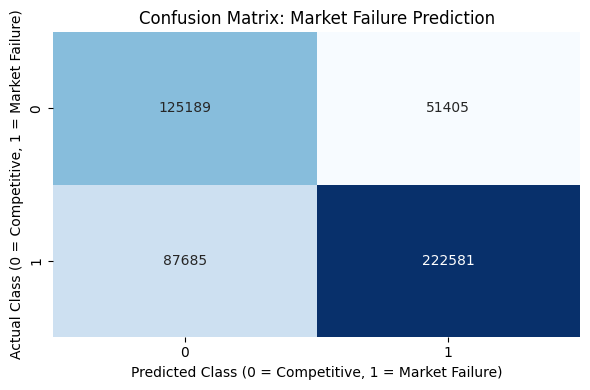

In [5]:
# ------------------------------------------------------------------------------
# STEP 3: Logistic Regression (Linear Baseline)
# ------------------------------------------------------------------------------
# Cost-sensitive learning is enabled via class_weight='balanced'
model_logreg = tune_supervised_model(
    X_train, y_train, groups_train, categorical_cols, numeric_cols, model_name='logreg'
)

# Extract probabilities for robust PR-AUC evaluation
preds_logreg = model_logreg.predict(X_test)
probs_logreg = model_logreg.predict_proba(X_test)[:, 1]

print("\n--- Evaluation: Logistic Regression ---")
evaluate_classification(y_test, preds_logreg, probs_logreg)
plot_confusion_matrix_heatmap(y_test, preds_logreg)

In [ ]:
# ------------------------------------------------------------------------------
# STEP 4: Decision Tree (Non-linear interactions)
# ------------------------------------------------------------------------------
model_dt = tune_supervised_model(
    X_train, y_train, groups_train, categorical_cols, numeric_cols, model_name='dt'
)

preds_dt = model_dt.predict(X_test)
probs_dt = model_dt.predict_proba(X_test)[:, 1]

print("\n--- Evaluation: Decision Tree ---")
evaluate_classification(y_test, preds_dt, probs_dt)
plot_confusion_matrix_heatmap(y_test, preds_dt)

# Plotting the driving rules behind single-bidding
plot_feature_importance(model_dt, numeric_cols, categorical_cols)